# T62 — Ophiolite emplacement paleo-map

**Cluster H: Paleo-geography.**

Ophiolites are fragments of oceanic lithosphere obducted onto a continental margin during arc-continent or continent-continent collision. Their emplacement age is a hard, mappable record of ocean closure — every ophiolite marks a place and time where an ocean disappeared. Plotted through deep time on paleo-Earth, they trace the birth and death of Wilson-cycle ocean basins across the Phanerozoic (and earlier).

## What this notebook produces

1. **§3 — Paleo-Earth map of one age.** Reconstruct all ophiolites older than the target age to their present-day host-plate position and forward to the target age, then plot symbols on a Zahirovic 2022 paleo-Earth. Symbol shape encodes tectonic setting (SSZ suprasubduction-zone / MOR mid-ocean ridge). Continents shown at target age.
2. **§4 — Snapshot mosaic.** Five ages (200, 150, 100, 60, 20 Ma) side-by-side, showing which ophiolites had already emplaced by each snapshot and where they had drifted to. Tells the story of Neo-Tethyan closure across the Late Cretaceous - Eocene.
3. **§5 — Emplacement-rate histogram through time.** Counts of ophiolite emplacements per 10-Myr bin, colour-coded by tectonic setting. Shows the well-known ~90 Ma emplacement peak (Semail, Troodos, Vardar, Yarlung-Tsangbo etc.).

## Learning objectives

- Load a point catalog with age + present-day coordinates, assign plate IDs by point-in-polygon against Z22 static polygons.
- Use `gplately.Points(..., time=age_ma).reconstruct(to_time=target_ma)` to move each ophiolite from its emplacement age forward to a common target age.
- Filter a point dataset by age (only plot ophiolites already emplaced by the target age).
- Encode categorical data (tectonic setting) as pyGMT symbol shape.
- Build a time-binned histogram of a catalog.

## Prerequisites and runtime

- Bundled data at `data/ophiolites/ophiolites_furnes2014_curated.csv` — 40 well-characterised ophiolites, 0-2000 Ma. Full ~500-ophiolite Furnes et al. (2014) compilation via the paper's supplementary tables (see Sources at the end).
- Python: `gplately`, `pygplates`, `pygmt`, `pandas`, `numpy`, `matplotlib`.
- Runtime: ~40 s (§3 + §4 render 6 pyGMT globes; §5 is a fast matplotlib histogram).


## Environment + imports


In [17]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0


In [18]:
# === USER CONFIGURATION =====================================================
MODEL_NAME          = "Zahirovic2022"            # PMM ID
ANCHOR_PLATE_ID     = 0                          # mantle frame — appropriate for
                                                 # tectonic-only (non-paleoclimate) work

# The single-age snapshot in §3 and the emplacement peak highlight in §5
RECONSTRUCTION_TIME = 95.0                       # Ma; ~Semail/Troodos peak

# Snapshot ages for the §4 mosaic (Neo-Tethyan closure sequence)
SNAPSHOT_AGES_MA    = [200, 150, 100, 60, 20]

# Ophiolite catalog + minimum age filter (drop Precambrian for §3/§4 since
# Z22 only covers 0-410 Ma; §5 histogram still shows the deep-time set).
OPHIOLITE_CSV       = Path("data/ophiolites/ophiolites_furnes2014_curated.csv")
MAX_AGE_FOR_MAP_MA  = 410                        # Z22 coverage limit

# Symbol style per tectonic setting
SYMBOL_STYLE = {
    "SSZ":     {"style": "t0.30c", "fill": "#e74c3c", "pen": "0.5p,black",
                "label": "Suprasubduction-zone (SSZ)"},
    "MOR":     {"style": "c0.28c", "fill": "#3498db", "pen": "0.5p,black",
                "label": "Mid-ocean-ridge (MOR)"},
}

# Emplacement-histogram bin width (Ma)
HIST_BIN_MA         = 10
# ============================================================================
print(f"  model:        {MODEL_NAME}")
print(f"  anchor:       {ANCHOR_PLATE_ID}")
print(f"  target time:  {RECONSTRUCTION_TIME} Ma")
print(f"  snapshots:    {SNAPSHOT_AGES_MA}")
print(f"  histogram:    {HIST_BIN_MA} Myr bins")


  model:        Zahirovic2022
  anchor:       0
  target time:  95.0 Ma
  snapshots:    [200, 150, 100, 60, 20]
  histogram:    10 Myr bins


## 1. Load the ophiolite catalog


In [19]:
# Skip commented header lines (rows starting with "#")
df = pd.read_csv(OPHIOLITE_CSV, comment="#")
print(f"  {len(df)} ophiolites loaded")
print(f"  age range: {df['age_ma'].min():.0f} - {df['age_ma'].max():.0f} Ma")
print(f"  tectonic settings: {df['tectonic_setting'].value_counts().to_dict()}")
df.head()


  40 ophiolites loaded
  age range: 1 - 3800 Ma
  tectonic settings: {'SSZ': 24, 'MOR': 16}


,name,age_ma,lat_deg,lon_deg,tectonic_setting,host_continent,notes
0,Semail (Oman),95,23.0,58.5,SSZ,Arabia,classic Late Cretaceous suprasubduction obduct...
1,Troodos (Cyprus),92,35.0,33.0,SSZ,Eurasia,Late Cretaceous marginal basin obducted during...
2,Bay of Islands (Newfoundland),486,49.5,-58.0,MOR,Laurentia,Cambro-Ordovician Iapetus MOR-type obducted in...
3,Coast Range (California),165,39.0,-123.0,SSZ,Laurentia,Middle Jurassic Franciscan-related back-arc/fo...
4,New Caledonia,37,-21.5,164.5,SSZ,Australia,Late Eocene obduction on New Caledonian passiv...


## 2. Build the plate model + assign plate IDs


In [20]:
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")

recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines"),
    plot_engine=gplately.PygmtPlotEngine(),
    continents=model.get_layer("ContinentalPolygons"),
    COBs=model.get_layer("COBs") if "COBs" in model.get_avail_layers() else None,
    time=RECONSTRUCTION_TIME,
    anchor_plate_id=ANCHOR_PLATE_ID,
)

# gplately.Points assigns plate IDs by point-in-polygon against the static polygons
map_df = df[df["age_ma"] <= MAX_AGE_FOR_MAP_MA].copy()
pts = gplately.Points(
    plate_reconstruction=recon,
    lons=map_df["lon_deg"].values,
    lats=map_df["lat_deg"].values,
    time=0,                        # sample locations known at present day
    anchor_plate_id=ANCHOR_PLATE_ID,
)
map_df["plate_id"] = pts.plate_id
print(f"  Assigned plate IDs to {len(map_df)} Phanerozoic ophiolites")
print(f"  Unique plate IDs: {sorted(set(map_df['plate_id']))[:10]}...")


  Assigned plate IDs to 25 Phanerozoic ophiolites
  Unique plate IDs: [105, 176, 178, 315, 329, 450, 501, 503, 602, 606]...


## 3. Reconstruct to the target age + plot on paleo-Earth

For each ophiolite, we reconstruct its **present-day** coordinate forward to `RECONSTRUCTION_TIME`. This shows where the ophiolite currently outcrops, but plotted on the paleo-Earth so continent positions match the target age. (An alternative would be to reconstruct to the *emplacement* age instead — but that has 40 different maps for 40 ophiolites and doesn't tell a coherent single-time story.)


In [21]:
def paleo_position(row, target_ma):
    """Reconstruct one ophiolite's present-day position to target_ma."""
    p = gplately.Points(
        plate_reconstruction=recon,
        lons=[row["lon_deg"]], lats=[row["lat_deg"]],
        time=0, plate_id=[row["plate_id"]],
        anchor_plate_id=ANCHOR_PLATE_ID,
    )
    rlons, rlats = p.reconstruct(time=float(target_ma), return_array=True,
                                  anchor_plate_id=ANCHOR_PLATE_ID)
    return float(rlons[0]), float(rlats[0])

# Only plot ophiolites already emplaced by RECONSTRUCTION_TIME
now_df = map_df[map_df["age_ma"] >= RECONSTRUCTION_TIME].copy()
rlons, rlats = [], []
for _, row in now_df.iterrows():
    lon, lat = paleo_position(row, RECONSTRUCTION_TIME)
    rlons.append(lon); rlats.append(lat)
now_df["paleo_lon"], now_df["paleo_lat"] = rlons, rlats
print(f"  Reconstructed {len(now_df)} ophiolites already emplaced by {RECONSTRUCTION_TIME:.0f} Ma")


  Reconstructed 11 ophiolites already emplaced by 95 Ma


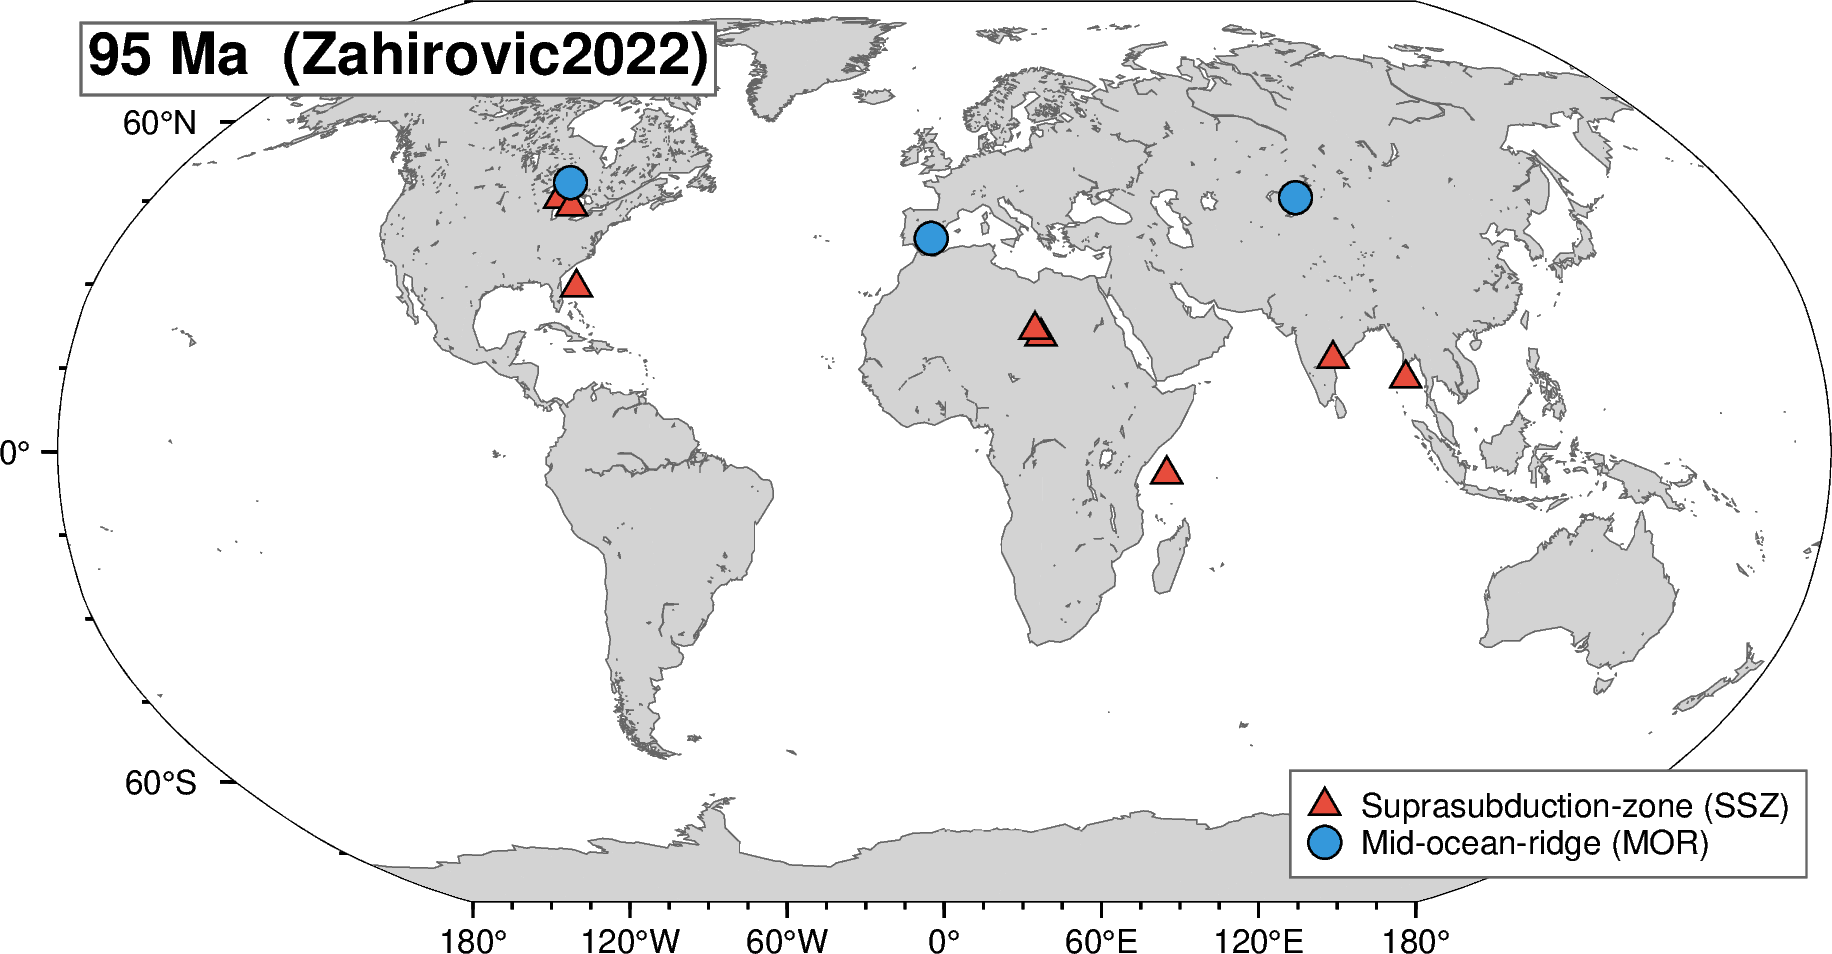

In [22]:
# House-style: one pygmt.Figure() per panel
fig = pygmt.Figure()
REGION, PROJ = [-180, 180, -90, 90], "N15c"

# Update gplot to the target time
gplot.time = RECONSTRUCTION_TIME

fig.basemap(region=REGION, projection=PROJ, frame="af")
fig.coast(region=REGION, projection=PROJ, land="lightgray", water="white",
          shorelines="0.25p,gray40")

# Continuous topological backbone (house-style)
try:
    # (engine now dispatched via gplately.PygmtPlotEngine on PlotTopologies)
    gplot.plot_all_topological_sections(fig, pen="0.5p,gray55")
except Exception:
    pass  # Older gplately versions may not expose the engine

# Continents
try:
    gplot.plot_continents(fig, fill="gray95", pen="0.5p,gray45")
except Exception:
    pass

# Ridges / trenches (styled) — layered on top of backbone
try:
    gplot.plot_ridges(fig, pen="0.7p,red")
    gplot.plot_subduction_teeth(fig, pen="0.7p,black")
except Exception:
    pass

# Ophiolite symbols by tectonic setting
for setting, style in SYMBOL_STYLE.items():
    sub = now_df[now_df["tectonic_setting"] == setting]
    if len(sub) == 0: continue
    fig.plot(x=sub["paleo_lon"], y=sub["paleo_lat"],
             style=style["style"], fill=style["fill"], pen=style["pen"],
             region=REGION, projection=PROJ, label=style["label"])

# House-style time stamp
fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")

fig.legend(position="JBR+jBR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1000)


### How to read the paleo-map

- **Red triangles (SSZ)** — ophiolites of *suprasubduction-zone* affinity. These formed in the upper plate of a subduction zone (forearc, back-arc, or intra-arc basin) and were obducted when the underlying ocean closed. Most Phanerozoic ophiolites are SSZ.
- **Blue circles (MOR)** — ophiolites of *mid-ocean-ridge* affinity. Formed at a spreading ridge, obducted onto a passive margin during continental collision. Less common but geochemically distinct.
- **Location** — each ophiolite is plotted at where its present-day host continent was located at `RECONSTRUCTION_TIME`. So an ophiolite in Oman today (Semail) shows up wherever Oman was at the target age, giving a paleo-tectonic map of ocean-closure events.

**Watch for**

- The Cretaceous Neo-Tethys chain — Semail (Oman), Troodos (Cyprus), Kizildag (Turkey), Vourinos + Mirdita (Balkans), Zagros (Iran), Xigaze + Yarlung-Tsangpo (Tibet) — should form a linear belt along the northern Gondwana margin at 95 Ma.
- The Iapetus record — Bay of Islands, Betts Cove, Mont Albert, Baltimore, Solund-Stavfjord, Karmøy, Peary Land — cluster around the Laurentia-Baltica-Avalonia margins in the Ordovician (~470-490 Ma) at older `RECONSTRUCTION_TIME` values.


## 4. Snapshot mosaic — five ages showing Neo-Tethyan closure

Same rendering as §3 but rendered as five separate figures (`SNAPSHOT_AGES_MA`) so you can compare cumulative ophiolite emplacement through time.


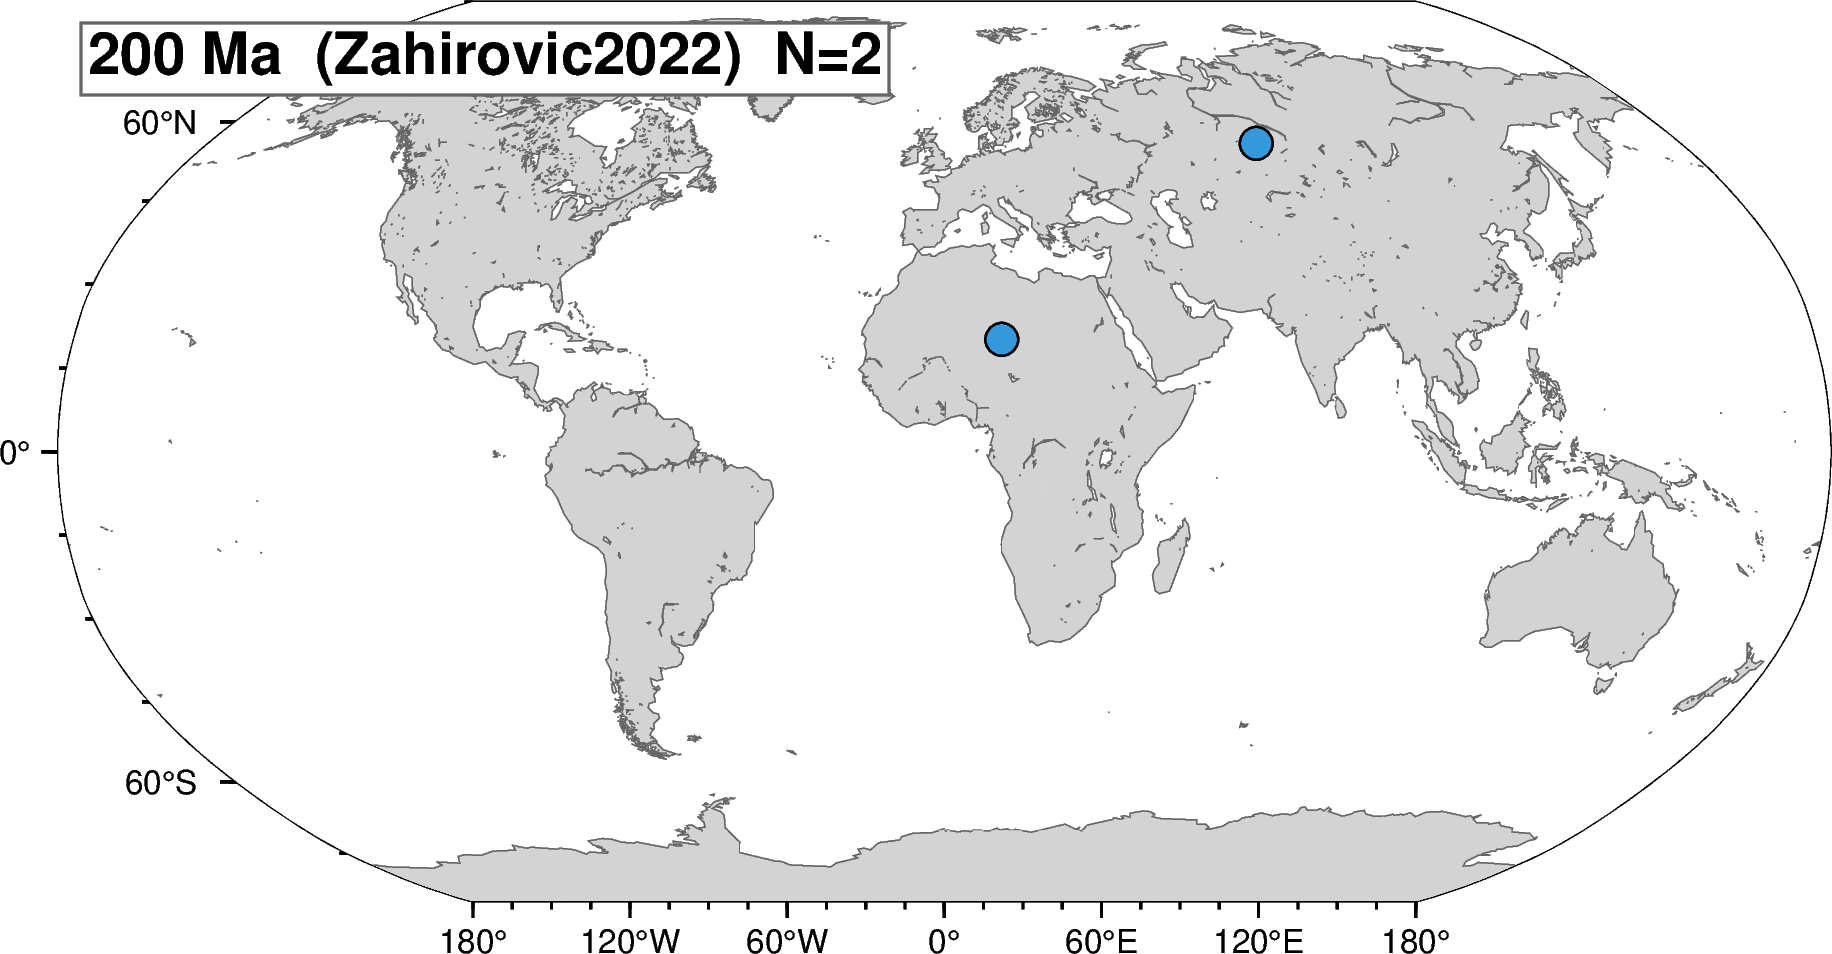

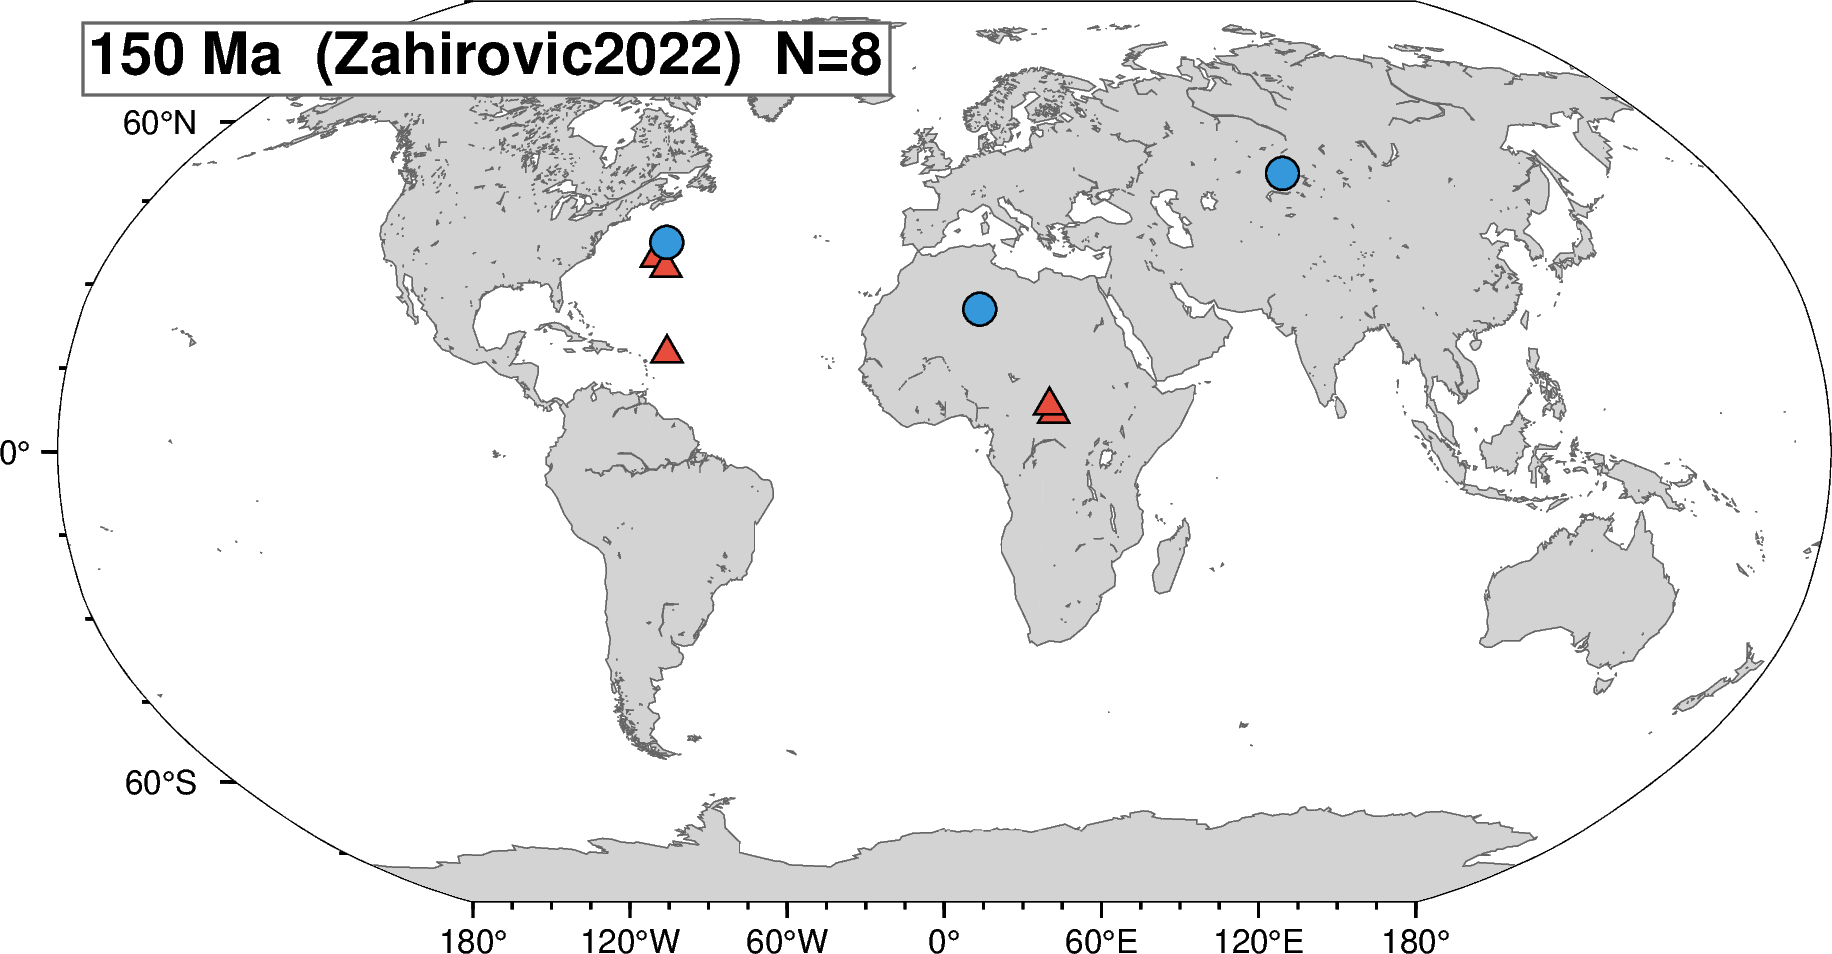

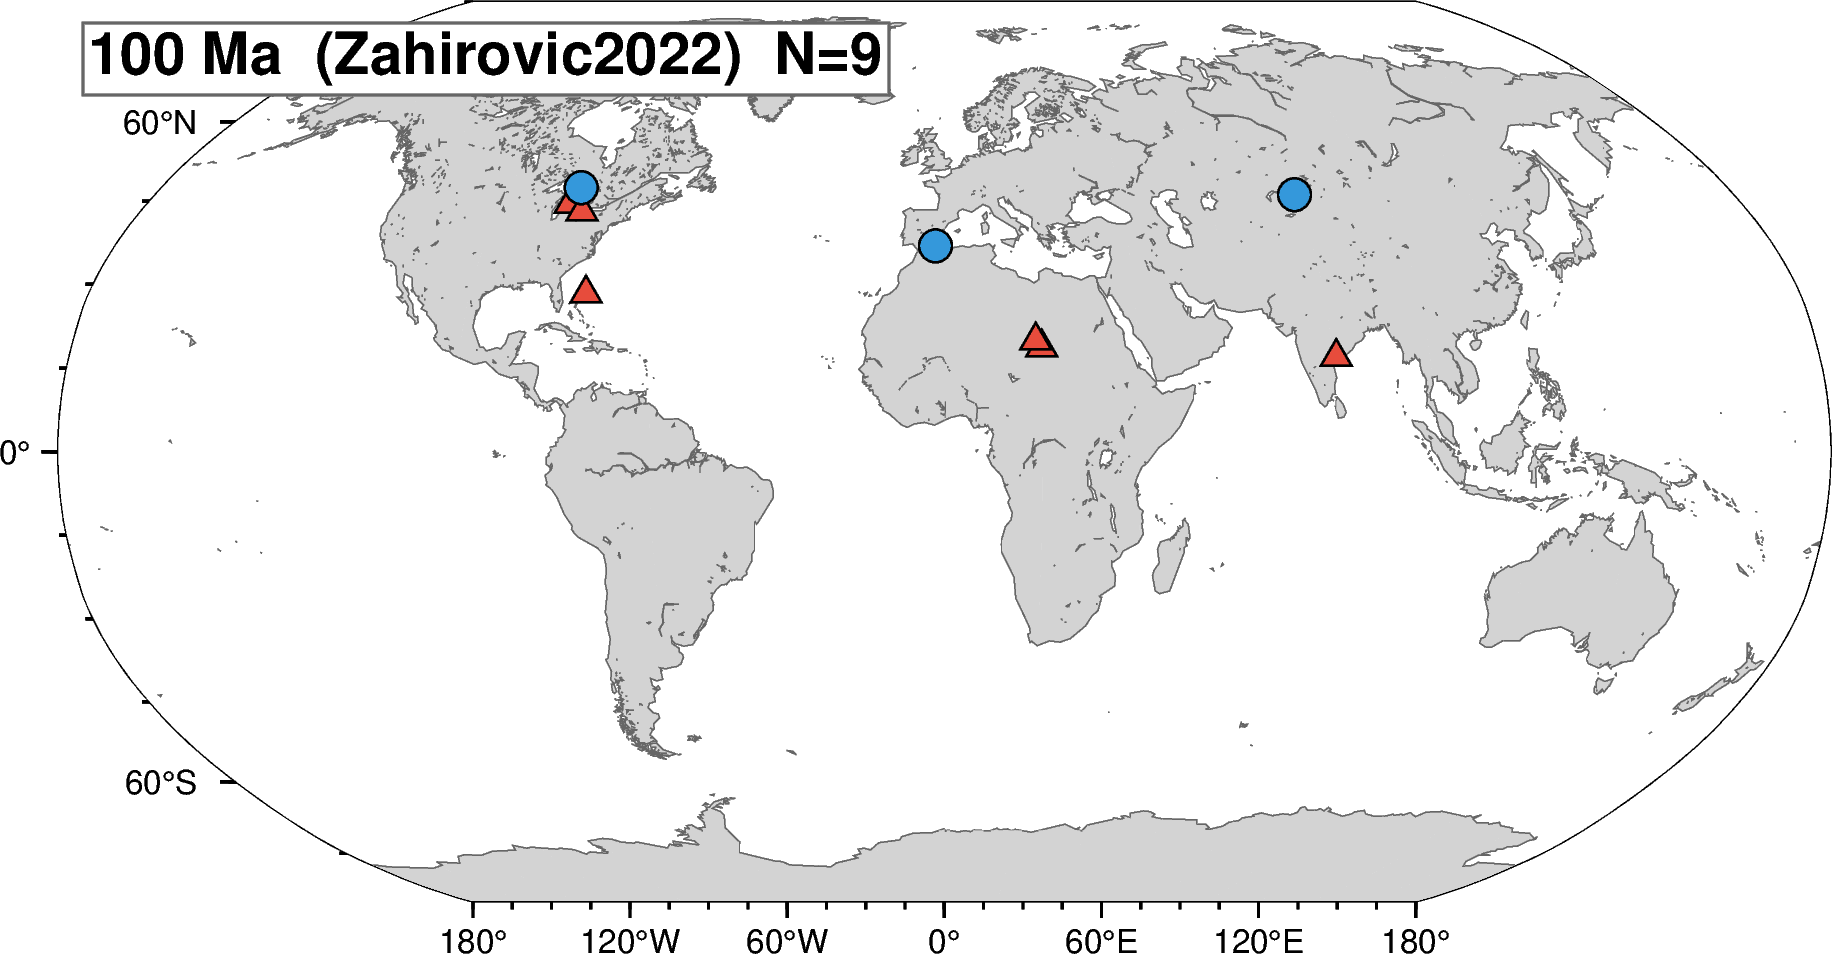

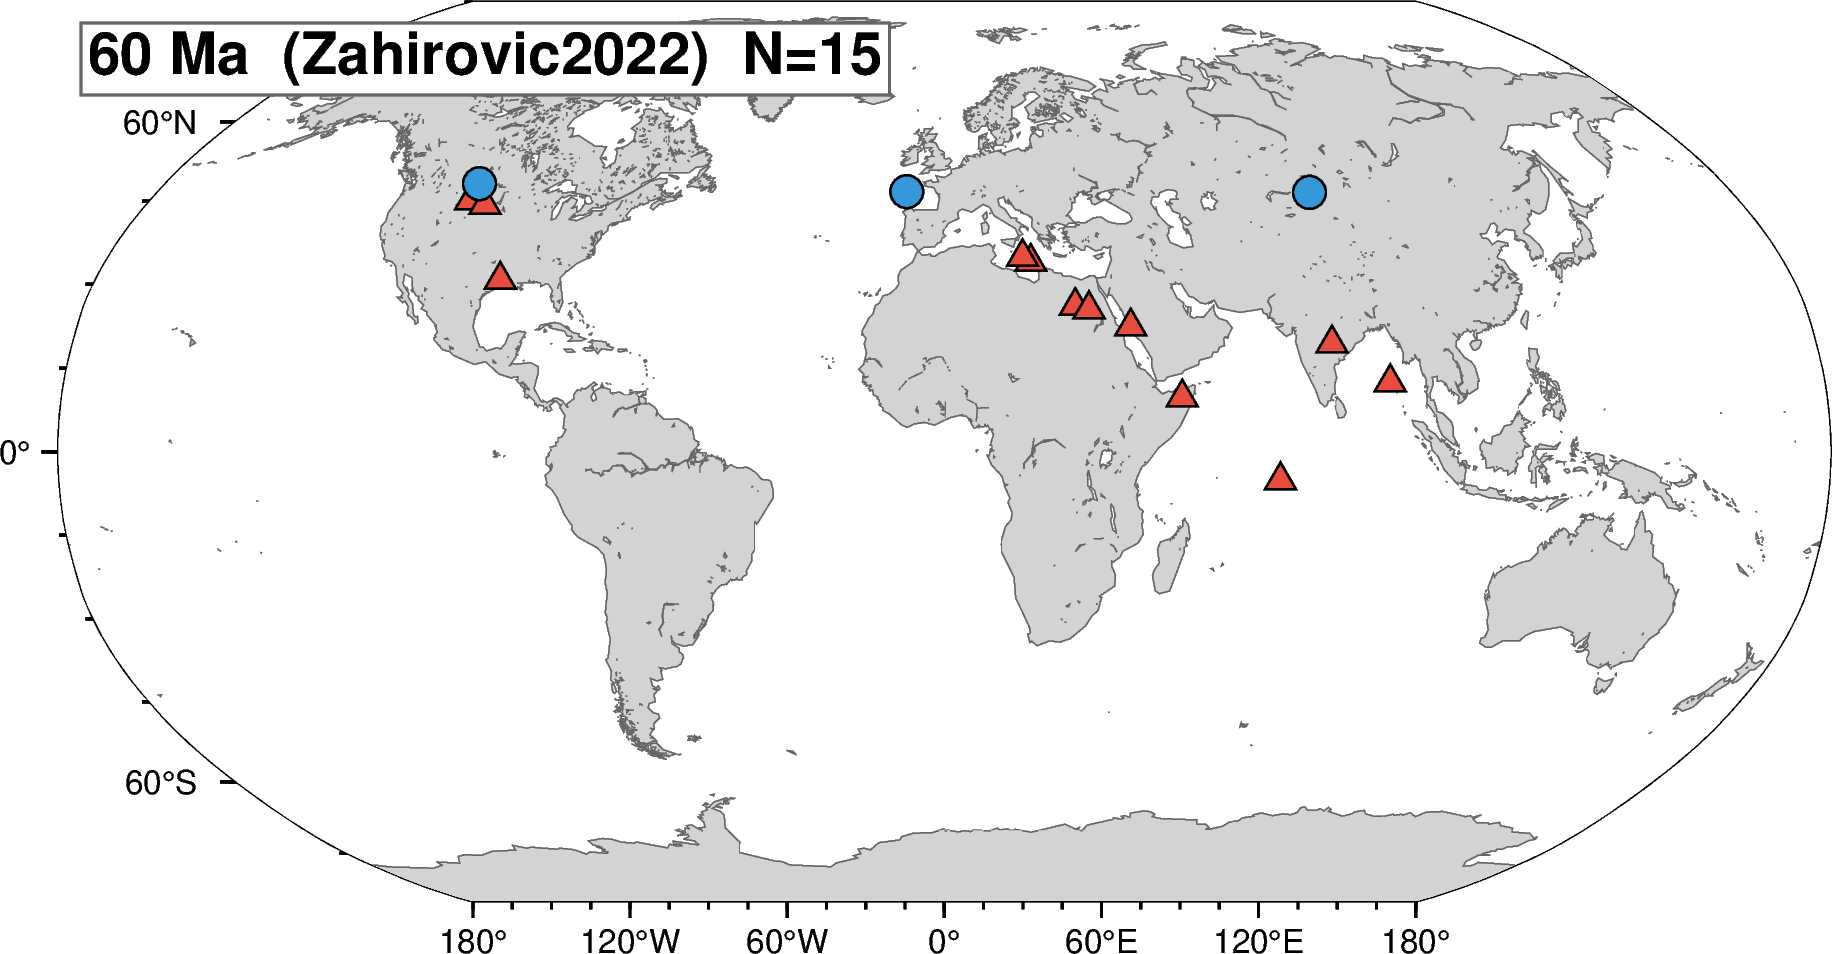

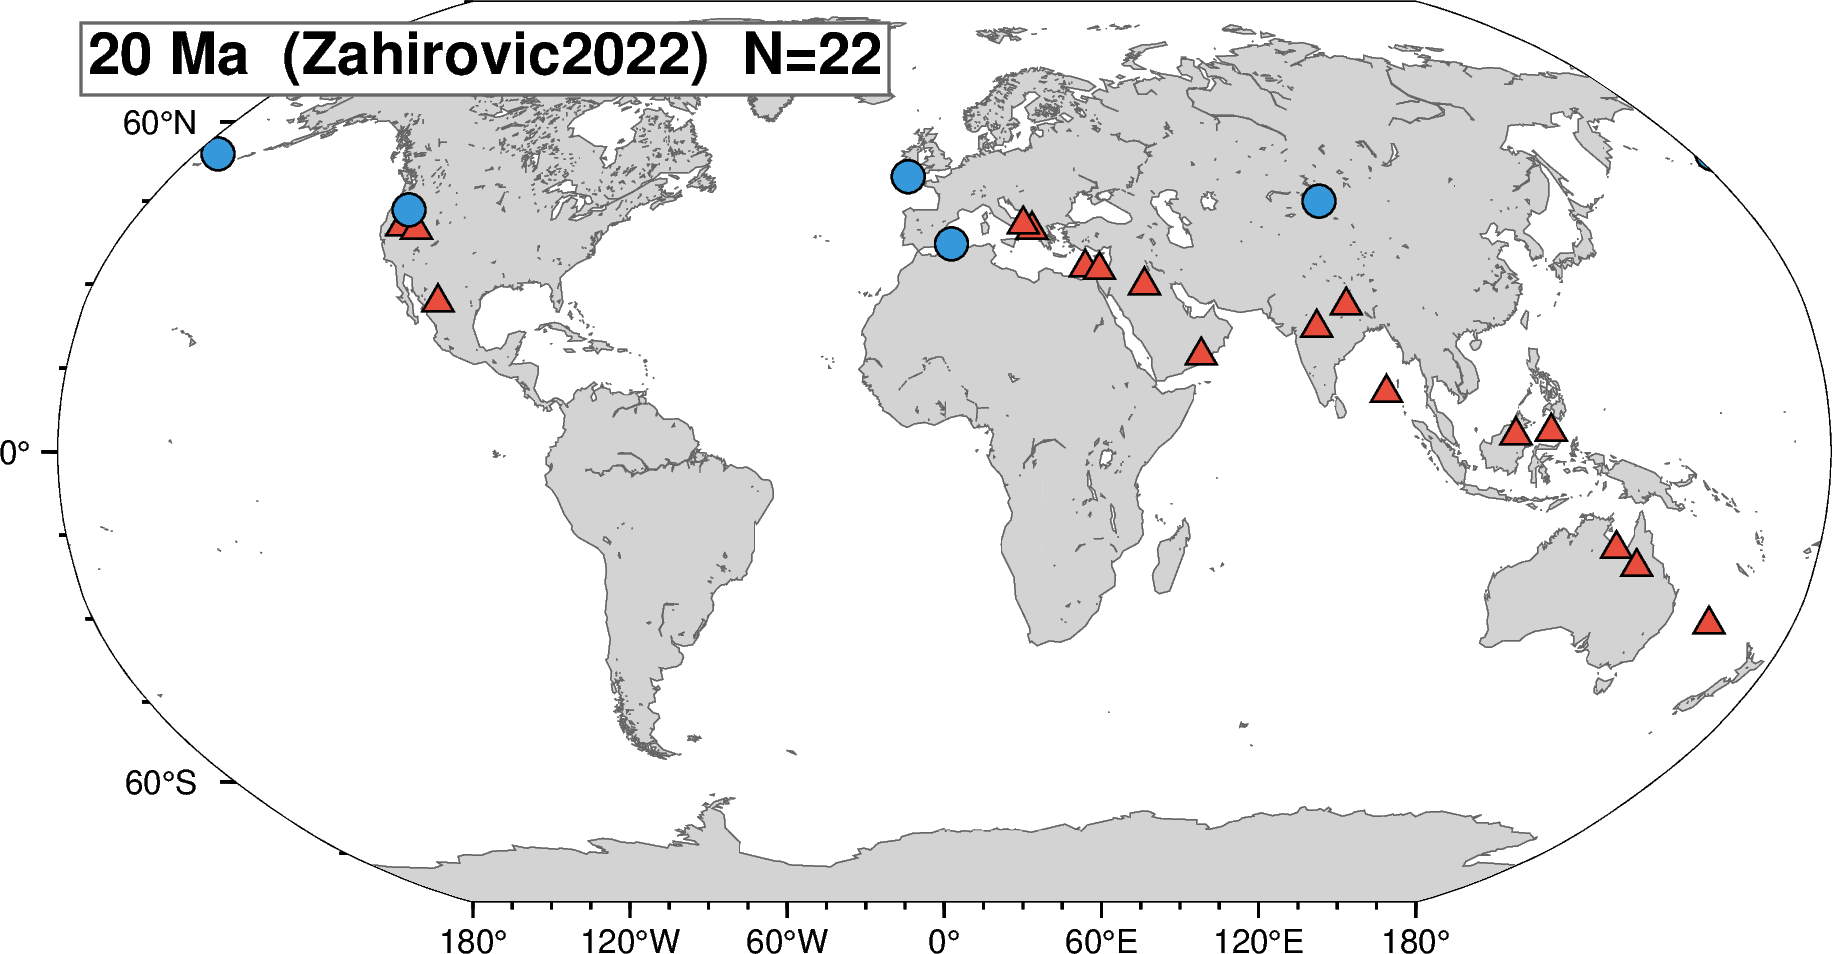

In [23]:
for age in SNAPSHOT_AGES_MA:
    # Snapshot filter: keep ophiolites already emplaced by this age
    snap_df = map_df[(map_df["age_ma"] >= age) & (map_df["age_ma"] <= MAX_AGE_FOR_MAP_MA)].copy()
    if len(snap_df) == 0:
        print(f"  {age} Ma: no ophiolites emplaced yet — skipping")
        continue

    # Reconstruct each ophiolite to this age
    rlons, rlats = [], []
    for _, row in snap_df.iterrows():
        lon, lat = paleo_position(row, age)
        rlons.append(lon); rlats.append(lat)
    snap_df["paleo_lon"], snap_df["paleo_lat"] = rlons, rlats

    fig = pygmt.Figure()
    gplot.time = age
    fig.basemap(region=REGION, projection=PROJ, frame="af")
    fig.coast(region=REGION, projection=PROJ, land="lightgray", water="white",
              shorelines="0.25p,gray40")
    try:
        gplot.plot_all_topological_sections(fig, pen="0.5p,gray55")
        gplot.plot_continents(fig, fill="gray95", pen="0.5p,gray45")
        gplot.plot_ridges(fig, pen="0.7p,red")
        gplot.plot_subduction_teeth(fig, pen="0.7p,black")
    except Exception:
        pass

    for setting, style in SYMBOL_STYLE.items():
        sub = snap_df[snap_df["tectonic_setting"] == setting]
        if len(sub) == 0: continue
        fig.plot(x=sub["paleo_lon"], y=sub["paleo_lat"],
                 style=style["style"], fill=style["fill"], pen=style["pen"],
                 region=REGION, projection=PROJ)

    fig.text(text=f"{age:.0f} Ma  ({MODEL_NAME})  N={len(snap_df)}",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
    fig.show(width=900)


### How to read the mosaic

- **200 Ma (Early Jurassic)** — most Phanerozoic ophiolites in the catalog have not yet been emplaced. Only pre-Mesozoic (Iapetus, Uralian, Paleo-Tethyan) examples appear. Sparse map.
- **150 Ma (Late Jurassic)** — Vardar and Xigaze suprasubduction ophiolites are just beginning to form; the Coast Range / Klamath / Baja SSZ complexes appear along the North American Cordillera.
- **100 Ma (mid-Cretaceous)** — the Neo-Tethyan SSZ ophiolites (proto-Semail, proto-Troodos) are being generated in the forearcs at their present-day host-continent positions. Cordilleran ophiolites still active.
- **60 Ma (Paleocene)** — Neo-Tethyan chain is fully emplaced. India-Asia ophiolites (Xigaze, Yarlung-Tsangpo) approach their final positions.
- **20 Ma (Miocene)** — SW Pacific ophiolites (New Caledonia, Papua, Sabah, Halmahera) added as the Australian and Pacific plates converge with the Sunda margin.


## 5. Emplacement-rate histogram

Counts of ophiolite emplacements per `HIST_BIN_MA`-Myr bin, coloured by tectonic setting. Uses the full catalog (all ages, including pre-410 Ma), so the histogram tells a deep-time story beyond Z22's paleo-map coverage.


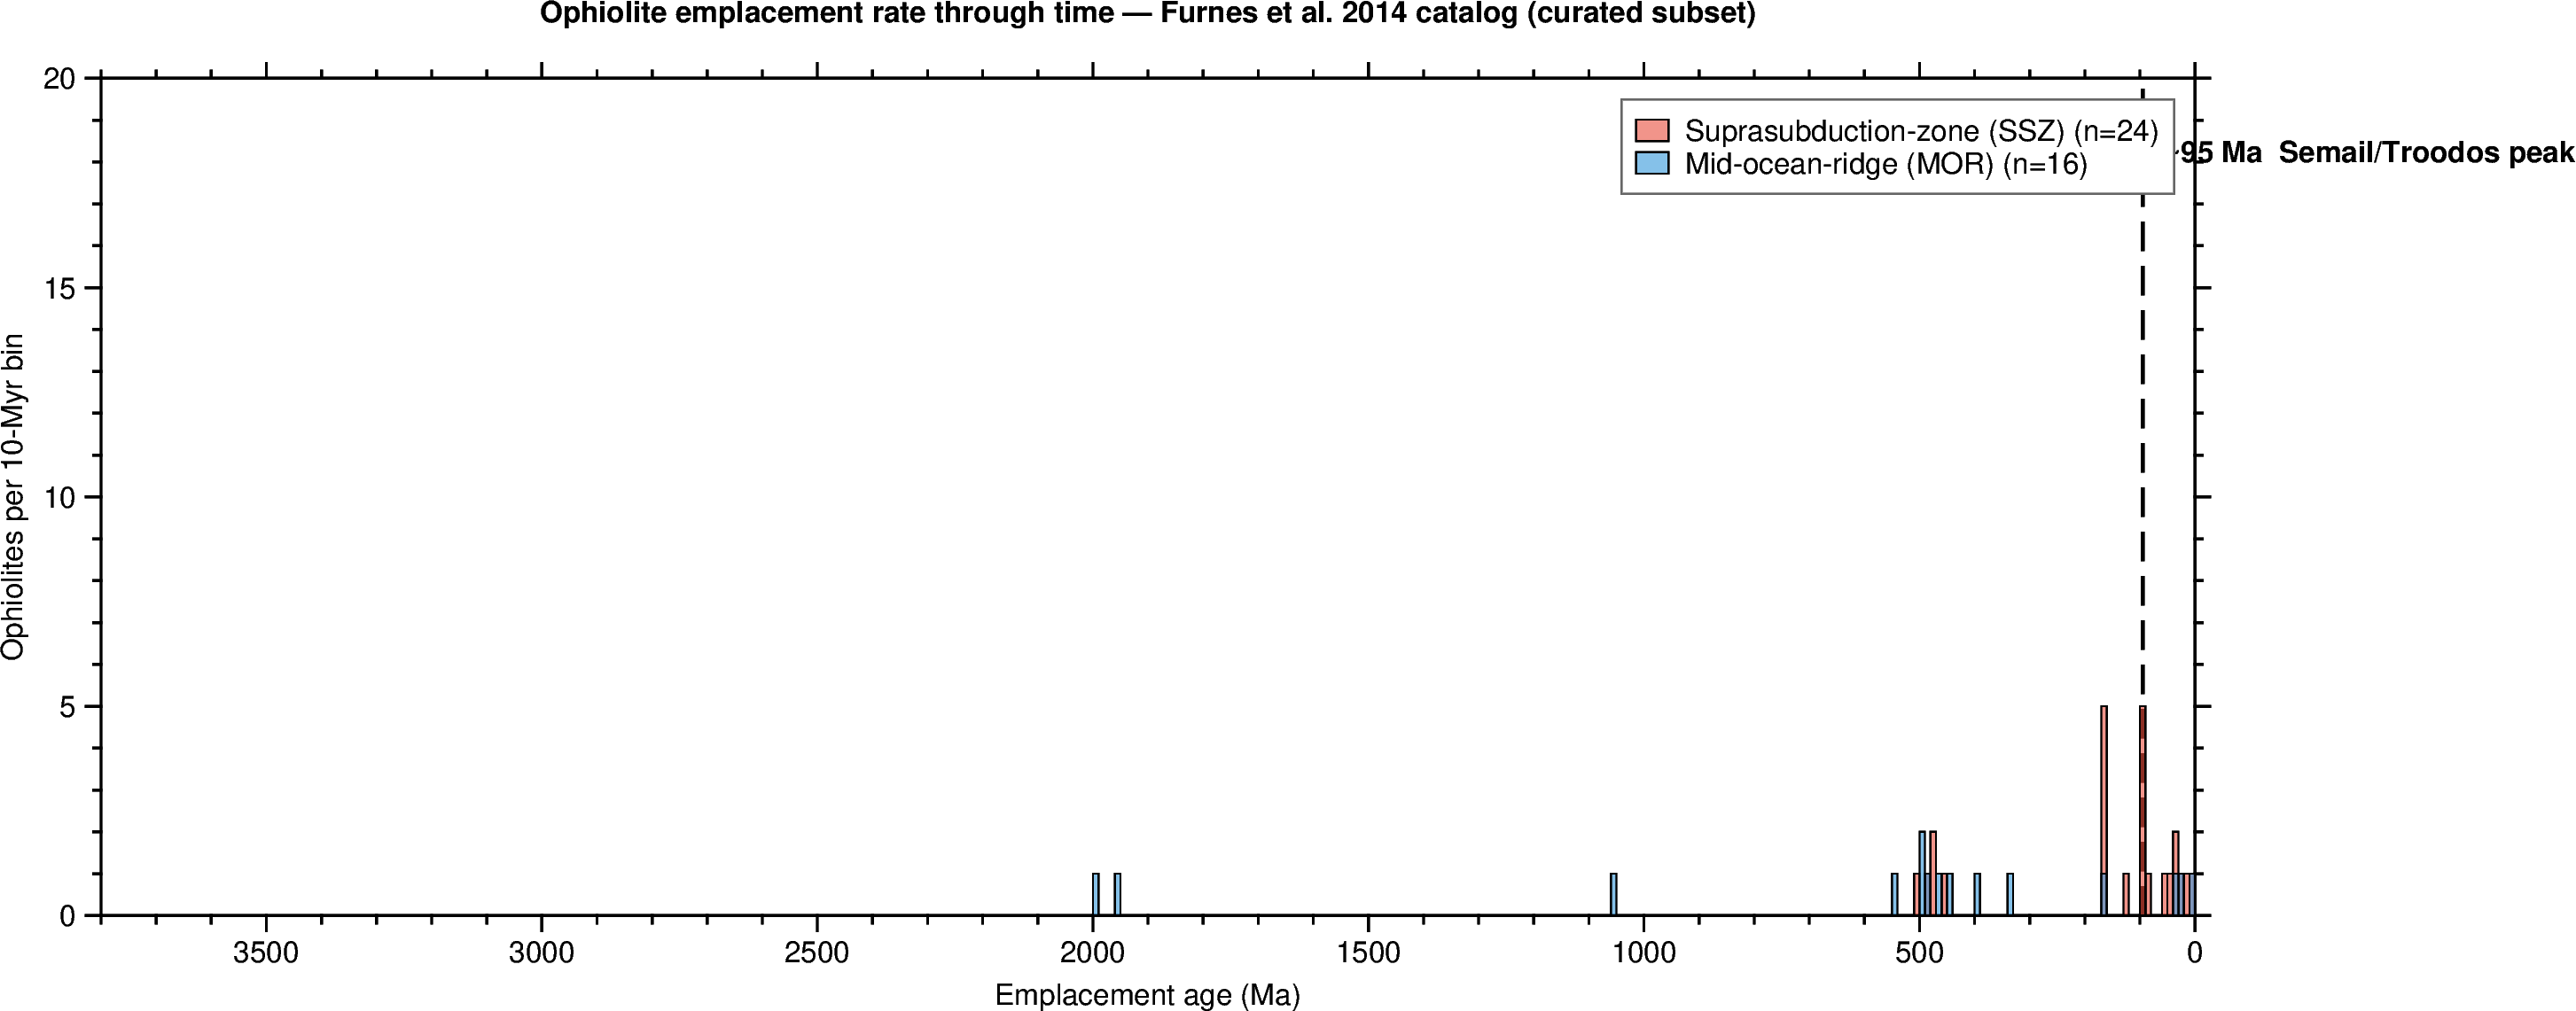

In [24]:
# Cap the x-axis at 2100 Ma so the two Paleoproterozoic examples
# (Purtuniq 1998 Ma, Jormua 1953 Ma) are visible without the Isua 3800 Ma
# scale-marker stretching the axis. Isua still contributes to §3 and §4.
max_age = 2100

fig = pygmt.Figure()
fig.basemap(region=[0, max_age, 0, 20], projection="X-20c/8c",
            frame=["WSne+tOphiolite emplacement rate through time — "
                   "Furnes et al. 2014 catalog (curated subset)",
                   "xa500f100+lEmplacement age (Ma)",
                   f"yaf+lOphiolites per {HIST_BIN_MA}-Myr bin"])

# ~95 Ma peak marker
fig.plot(x=[95, 95], y=[0, 20], pen="1p,black,-")
fig.text(x=95, y=18, text="~95 Ma  Semail/Troodos peak",
         font="8p,Helvetica-Bold,black", justify="LB", offset="0.2c/0c", no_clip=True)

# Overlapping histograms per host class (not stacked — pyGMT.histogram makes a fresh y-axis
# per call). Use transparency so overlaps are visible.
for setting, style in SYMBOL_STYLE.items():
    sub = df[df["tectonic_setting"] == setting]
    if len(sub) == 0: continue
    fig.histogram(data=sub["age_ma"].values,
                  series=f"0/{max_age}/{HIST_BIN_MA}",
                  pen="0.4p,black", fill=f"{style['fill']}@40",
                  region=[0, max_age, 0, 20], projection="X-20c/8c",
                  label=style["label"] + f" (n={len(sub)})")

fig.legend(position="JTR+jTR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1100)


### How to read the histogram

- **~95 Ma peak** — the classic mid-Cretaceous ophiolite emplacement peak, dominated by Neo-Tethyan SSZ complexes (Semail, Troodos, Kizildag, Vourinos, Xigaze, Yarlung-Tsangpo). Marks a Wilson-cycle-scale ocean-closure phase.
- **~490 Ma peak** — Iapetus and Paleo-Asian ocean SSZ + MOR complexes emplaced during Caledonian / Taconic / Kunlun orogenies.
- **~160 Ma peak** — a smaller peak from Vardar and Cordilleran SSZ complexes.
- **Cenozoic tail** — arc-continent collisions in the SW Pacific + Papua provide a steady stream of young ophiolites.

**Full-catalog context**: Furnes et al. (2014, *Geoscience Frontiers*) show a similar structure with 500+ ophiolites back to ~3.8 Ga. The Precambrian tail (Purtuniq, Jormua, Chaya, Isua) is barely visible in this curated subset because we have only ~5 examples. Loading the full catalog would show clear Paleoproterozoic (~2.0 Ga) and Neoproterozoic (~800 Ma) peaks tied to Nuna and Rodinia assembly.


## Extend this

- **Load the full Furnes 2014 catalog.** The supplementary tables of Furnes, De Wit & Dilek (2014) at <https://doi.org/10.1016/j.gsf.2014.02.002> list ~500 ophiolites back to 3.8 Ga with age, coordinates, tectonic setting, and geochemistry. Drop it into `data/ophiolites/` in the same schema and the notebook picks it up.
- **Colour by geochemical affinity.** The Furnes catalog subdivides SSZ ophiolites into forearc / back-arc / intra-arc based on trace-element ratios. Add a `geochem_affinity` column and switch the symbol colouring.
- **Cross-reference with the zircon suite (T19-T22).** Ophiolite obduction ages should correlate with SSZ zircon-crystallisation peaks — plot the two histograms on shared axes.
- **Overlay LIP emplacement events.** Ernst (2014) catalog of large igneous provinces gives another point-source deep-time dataset that could ride on the same paleo-Earth infrastructure.
- **Reconstruct to the emplacement age instead of a common target age.** Each ophiolite ends up on the paleo-globe at its exact obduction time — useful for building a `.gif` animation of ocean closure.

## Related notebooks

- **T19-T22** — Wu 2023 zircon trio: detrital / igneous / metamorphic zircons on paleo-Earth. Same reconstruction-to-paleo-position pattern.
- **T41** — reef builders paleolatitude (Boucot 1999 catalog): another point dataset in paleo-position.
- **T44** — Boucot climate-sensitive lithologies: same paleo-latitude workflow.

## Sources

- Furnes, H., De Wit, M. & Dilek, Y. (2014). Four billion years of ophiolites reveal secular trends in oceanic crust formation. *Geoscience Frontiers* 5(4), 571-603. doi:10.1016/j.gsf.2014.02.002.
- Dilek, Y. & Furnes, H. (2011). Ophiolite genesis and global tectonics: Geochemical and tectonic fingerprinting of ancient oceanic lithosphere. *Geological Society of America Bulletin* 123(3-4), 387-411. doi:10.1130/B30446.1.
- Furnes, H., Dilek, Y. & de Wit, M. (2015). Precambrian greenstone sequences represent different ophiolite types. *Gondwana Research* 27(2), 649-685. doi:10.1016/j.gr.2013.06.004.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. doi:10.1002/gdj3.146.
